# Association Dataset


To get started, we import the balance and visualization modules along with the CSV-parsing helpers from the CLI.


In [1]:
from pprint import pprint

import matplotlib.pyplot as plt

from netbalance.viz import draw_bipartite_graph
from netbalance import balance
from netbalance.cli import encode, decode, read_input
import io

The input is a CSV string (or file) where the first N columns are entity names — one per group — and the last column is a binary interaction label ( = positive, = negative). The header names the groups.


In [2]:
csv_text = """A,B,interaction
A1,B2,1
A1,B4,1
A2,B5,1
A3,B1,1
A3,B6,1
A4,B3,1
A5,B4,1
A6,B5,1
A1,B1,0
A2,B1,0
A2,B2,0
A2,B3,0
A3,B2,0
A3,B5,0
A4,B4,0
A5,B5,0
A6,B2,0
A6,B3,0
A6,B6,0
"""

header, rows = read_input(io.StringIO(csv_text), sep=",")
associations, node_names = encode(rows, n_clusters=len(header) - 1)

print(f"Groups: {header[:-1]}")
print(f"Nodes per group: {[len(g) for g in node_names]}")
print(f"Total edges: {len(associations)}")

Groups: ['A', 'B']
Nodes per group: [6, 6]
Total edges: 19


The following plot visualises the association graph. Positive associations are shown with green edges, negative with red. The rings around each node indicate the proportion of positive (green) and negative (red) associations.


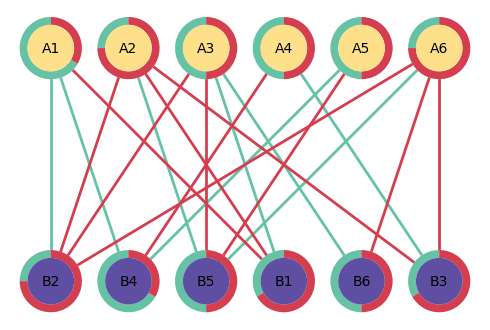

In [3]:
fig, ax = plt.subplots(figsize=(5, 6))
draw_bipartite_graph(associations, node_names[0], node_names[1], ax)
fig.tight_layout()

As you can see, this dataset is neither balanced nor entity-balanced.
It is not balanced because the number of negative edges is greater than the number of positive ones. It is not entity-balanced because, for many nodes, the proportion of positive and negative associations is not equal.

We can use to inspect the dataset:


In [4]:
pprint(balance.compute_stats(associations, node_names))

{'a': {'ent': 0.9076408288409856,
       'num': array([3., 4., 4., 2., 2., 4.]),
       'num_neg': array([1., 3., 2., 1., 1., 3.]),
       'num_pos': array([2., 1., 2., 1., 1., 1.]),
       'ratio': array([0.66666778, 0.25000187, 0.50000125, 0.5000025 , 0.5000025 ,
       0.25000187])},
 'b': {'ent': 0.9215703771363559,
       'num': array([4., 3., 4., 3., 2., 3.]),
       'num_neg': array([3., 1., 2., 2., 1., 2.]),
       'num_pos': array([1., 2., 2., 1., 1., 1.]),
       'ratio': array([0.25000187, 0.66666778, 0.50000125, 0.33333556, 0.5000025 ,
       0.33333556])},
 'ent': 0.9146056029886708}


This function returns a dictionary containing various statistics about the dataset.  It has a key for each group name, plus an `'ent'` key indicating the entropy of the dataset. The value for each group is another dictionary containing the following information:

- **`'ent'`**: Entropy of the group.  
- **`'num'`**: A list of numbers indicating the total number of positive and negative associations for each node.  
- **`'num_neg'`**: Same as `'num'`, but only for negative associations.  
- **`'num_pos'`**: Same as `'num'`, but only for positive associations.  
- **`'r'`**: A list of ratios representing the number of positives to the total number of associations for each node.  
  - A value of `0.5` indicates the group is **entity-balanced**.  
  - The closer the value is to `0` or `1`, the more **entity-unbalanced** it is.



## Make the Association Data Balanced


To make our dataset balanced, we use . This randomly selects negative samples so that the number of positives and negatives is equal.


In [5]:
balanced_assoc = balance.balanced(
    associations,
    node_names,
    negative_ratio=1.0,
    seed=0,
)

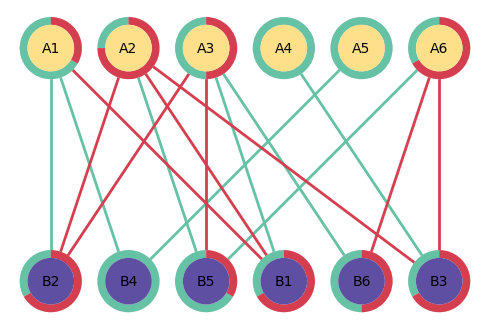

In [6]:
fig, ax = plt.subplots(figsize=(5, 6))
draw_bipartite_graph(balanced_assoc, node_names[0], node_names[1], ax)
fig.tight_layout()

In [7]:
pprint(balance.compute_stats(balanced_assoc, node_names))

{'a': {'ent': 0.7971860193604254,
       'num': array([3., 4., 4., 1., 1., 3.]),
       'num_neg': array([1., 3., 2., 0., 0., 2.]),
       'num_pos': array([2., 1., 2., 1., 1., 1.]),
       'ratio': array([0.66666778, 0.25000187, 0.50000125, 1.        , 1.        ,
       0.33333556])},
 'b': {'ent': 0.8137267232057687,
       'num': array([3., 2., 3., 3., 2., 3.]),
       'num_neg': array([2., 0., 1., 2., 1., 2.]),
       'num_pos': array([1., 2., 2., 1., 1., 1.]),
       'ratio': array([0.33333556, 1.        , 0.66666778, 0.33333556, 0.5000025 ,
       0.33333556])},
 'ent': 0.8054563712830971}


As you can see, the number of positive and negative associations is now the same; however, it is even more entity-unbalanced.


## Make the Association Data Entity-Balanced


We can use to produce a dataset that is both balanced _and_ entity-balanced. This uses simulated annealing to optimise per-entity degree entropy.


In [8]:
eb_assoc = balance.entity_balanced(
    associations,
    node_names,
    negative_ratio=1.0,
    seed=0,
    max_iter=1000,
    delta=0.1,
    cooling_rate=0.99,
    initial_temp=10.0,
    ent_desired=1.0,
)

Now the dataset is both balanced and entity-balanced.


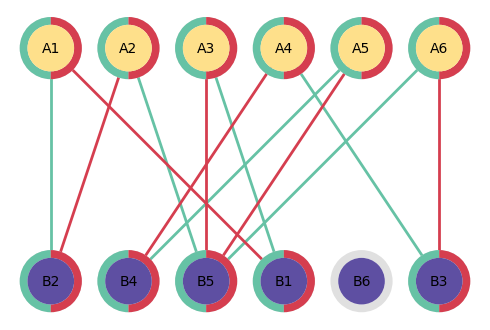

In [9]:
fig, ax = plt.subplots(figsize=(5, 6))
draw_bipartite_graph(eb_assoc, node_names[0], node_names[1], ax)
fig.tight_layout()

In [10]:
pprint(balance.compute_stats(eb_assoc, node_names))

{'a': {'ent': 1.0000044265454675,
       'num': array([2., 2., 2., 2., 2., 2.]),
       'num_neg': array([1., 1., 1., 1., 1., 1.]),
       'num_pos': array([1., 1., 1., 1., 1., 1.]),
       'ratio': array([0.5000025, 0.5000025, 0.5000025, 0.5000025, 0.5000025, 0.5000025])},
 'b': {'ent': 1.0000036887476556,
       'num': array([2., 2., 4., 2., 0., 2.]),
       'num_neg': array([1., 1., 2., 1., 0., 1.]),
       'num_pos': array([1., 1., 2., 1., 0., 1.]),
       'ratio': array([0.5000025 , 0.5000025 , 0.50000125, 0.5000025 , 1.        ,
       0.5000025 ])},
 'ent': 1.0000040576465614}


### Generating Diverse Datasets with Different Seeds


If we change the , we can generate different entity-balanced datasets from the same input.


In [11]:
eb_assoc_s1 = balance.entity_balanced(
    associations,
    node_names,
    negative_ratio=1.0,
    seed=1,
    max_iter=1000,
    delta=0.1,
    cooling_rate=0.99,
    initial_temp=10.0,
    ent_desired=1.0,
)

With and the same data, we obtain a different entity-balanced dataset.


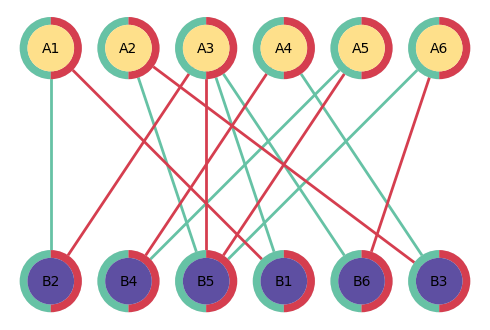

In [12]:
fig, ax = plt.subplots(figsize=(5, 6))
draw_bipartite_graph(eb_assoc_s1, node_names[0], node_names[1], ax)
fig.tight_layout()

In [13]:
pprint(balance.compute_stats(eb_assoc_s1, node_names))

{'a': {'ent': 1.000003794150053,
       'num': array([2., 2., 4., 2., 2., 2.]),
       'num_neg': array([1., 1., 2., 1., 1., 1.]),
       'num_pos': array([1., 1., 2., 1., 1., 1.]),
       'ratio': array([0.5000025 , 0.5000025 , 0.50000125, 0.5000025 , 0.5000025 ,
       0.5000025 ])},
 'b': {'ent': 1.000003794150053,
       'num': array([2., 2., 4., 2., 2., 2.]),
       'num_neg': array([1., 1., 2., 1., 1., 1.]),
       'num_pos': array([1., 1., 2., 1., 1., 1.]),
       'ratio': array([0.5000025 , 0.5000025 , 0.50000125, 0.5000025 , 0.5000025 ,
       0.5000025 ])},
 'ent': 1.000003794150053}


## Creating Datasets with Different Levels of Entity-Balance


The parameter controls the target entropy. Setting produces a maximally entity-*un*balanced dataset.


In [14]:
eb_unbal = balance.entity_balanced(
    associations,
    node_names,
    negative_ratio=1.0,
    seed=1,
    max_iter=1000,
    delta=1.0,
    cooling_rate=0.99,
    initial_temp=10.0,
    ent_desired=0.0,
)

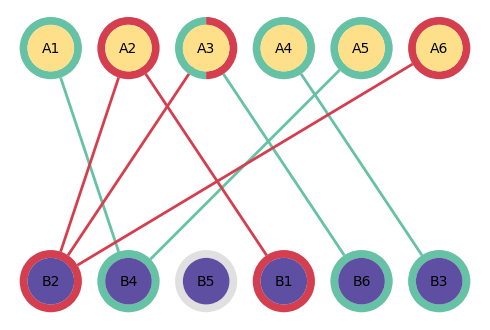

In [15]:
fig, ax = plt.subplots(figsize=(5, 6))
draw_bipartite_graph(eb_unbal, node_names[0], node_names[1], ax)
fig.tight_layout()

In [16]:
pprint(balance.compute_stats(eb_unbal, node_names))

{'a': {'ent': 0.2500185147582477,
       'num': array([1., 2., 2., 1., 1., 1.]),
       'num_neg': array([0., 2., 1., 0., 0., 1.]),
       'num_pos': array([1., 0., 1., 1., 1., 0.]),
       'ratio': array([1.000000e+00, 4.999975e-06, 5.000025e-01, 1.000000e+00,
       1.000000e+00, 9.999900e-06])},
 'b': {'ent': 1.928312260608983e-05,
       'num': array([3., 2., 0., 1., 1., 1.]),
       'num_neg': array([3., 0., 0., 1., 0., 0.]),
       'num_pos': array([0., 2., 0., 0., 1., 1.]),
       'ratio': array([3.33332222e-06, 1.00000000e+00, 1.00000000e+00, 9.99990000e-06,
       1.00000000e+00, 1.00000000e+00])},
 'ent': 0.1250188989404269}


## More than Two Groups in Association Data


It is also possible to specify more than two entity groups. Here we define three groups (A, B, C) using the same CSV format.


In [17]:
csv_3g = """A,B,C,interaction
A1,B2,C1,1
A1,B4,C2,1
A2,B5,C1,1
A3,B1,C2,1
A3,B6,C2,1
A4,B3,C2,1
A5,B4,C1,1
A6,B5,C1,1
A1,B1,C2,0
A2,B1,C2,0
A2,B2,C2,0
A2,B3,C3,0
A3,B2,C3,0
A3,B5,C1,0
A4,B4,C3,0
A5,B5,C3,0
A6,B2,C3,0
A6,B3,C2,0
A6,B6,C3,0
"""

header_3g, rows_3g = read_input(io.StringIO(csv_3g), sep=",")
assoc_3g, names_3g = encode(rows_3g, n_clusters=len(header_3g) - 1)

print(f"Groups: {header_3g[:-1]}")
print(f"Nodes per group: {[len(g) for g in names_3g]}")

Groups: ['A', 'B', 'C']
Nodes per group: [6, 6, 3]


In [18]:
pprint(balance.compute_stats(assoc_3g, names_3g))

{'a': {'ent': 0.9076408288409856,
       'num': array([3., 4., 4., 2., 2., 4.]),
       'num_neg': array([1., 3., 2., 1., 1., 3.]),
       'num_pos': array([2., 1., 2., 1., 1., 1.]),
       'ratio': array([0.66666778, 0.25000187, 0.50000125, 0.5000025 , 0.5000025 ,
       0.25000187])},
 'b': {'ent': 0.9215703771363559,
       'num': array([4., 3., 4., 3., 2., 3.]),
       'num_neg': array([3., 1., 2., 2., 1., 2.]),
       'num_pos': array([1., 2., 2., 1., 1., 1.]),
       'ratio': array([0.25000187, 0.66666778, 0.50000125, 0.33333556, 0.5000025 ,
       0.33333556])},
 'c': {'ent': 0.6110363937326325,
       'num': array([5., 8., 6.]),
       'num_neg': array([1., 4., 6.]),
       'num_pos': array([4., 4., 0.]),
       'ratio': array([8.00000400e-01, 5.00000625e-01, 1.66666389e-06])},
 'ent': 0.8134158665699913}


In [19]:
eb_3g = balance.entity_balanced(
    assoc_3g,
    names_3g,
    negative_ratio=1.0,
    seed=0,
    max_iter=1000,
    delta=0.1,
    cooling_rate=0.99,
    initial_temp=10.0,
    ent_desired=1.0,
)

pprint(balance.compute_stats(eb_3g, names_3g))

{'a': {'ent': 1.0000044265410408,
       'num': array([2., 2., 2., 2., 0., 2.]),
       'num_neg': array([1., 1., 1., 1., 0., 1.]),
       'num_pos': array([1., 1., 1., 1., 0., 1.]),
       'ratio': array([0.5000025, 0.5000025, 0.5000025, 0.5000025, 1.       , 0.5000025])},
 'b': {'ent': 0.9509814991598826,
       'num': array([0., 2., 3., 3., 0., 2.]),
       'num_neg': array([0., 1., 1., 2., 0., 1.]),
       'num_pos': array([0., 1., 2., 1., 0., 1.]),
       'ratio': array([1.        , 0.5000025 , 0.66666778, 0.33333556, 1.        ,
       0.5000025 ])},
 'c': {'ent': 0.8754928612609567,
       'num': array([3., 6., 1.]),
       'num_neg': array([1., 3., 1.]),
       'num_pos': array([2., 3., 0.]),
       'ratio': array([6.66667778e-01, 5.00000833e-01, 9.99990000e-06])},
 'ent': 0.9421595956539601}


## Writing Results Back to CSV


Use to convert the integer-indexed result back to named entities, then write to any output format.


In [20]:
decoded_rows = decode(eb_assoc, node_names)

# Print first 5 rows
print(",".join(header))
for row in decoded_rows[:5]:
    print(",".join(row))
print("...")

A,B,interaction
A4,B3,1
A6,B5,1
A6,B3,0
A1,B1,0
A3,B1,1
...
